<a href="https://colab.research.google.com/github/BhuvanSaraf/Underwater-Image-Enhancement-UIEB-AI-project-/blob/U-type/Notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Initializations

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
import time
import albumentations as A


# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Copy the file to local Colab storage
!cp /content/drive/MyDrive/Train_Val_Dataset/Train_Val_Dataset.zip /content/

# Unzip it quietly (-q)
!unzip -q /content/Train_Val_Dataset.zip -d /content

In [4]:
def load_images_to_numpy(raw_path, ref_path):
    raw_list, ref_list = [], []

    # Filter for image files only
    raw_files = sorted([f for f in os.listdir(raw_path) if f.endswith(('.png'))])
    ref_files = sorted([f for f in os.listdir(ref_path) if f.endswith(('.png'))])

    for r_f, g_f in zip(raw_files, ref_files):
        # Load, resize
        img_raw = cv2.imread(os.path.join(raw_path, r_f))
        img_ref = cv2.imread(os.path.join(ref_path, g_f))
        #color settings?
        img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        img_ref = cv2.cvtColor(img_ref, cv2.COLOR_BGR2RGB)

        if img_raw is not None and img_ref is not None:
            # Resize and flatten
            raw_flat = cv2.resize(img_raw, (256, 256)) / 255.0
            ref_flat = cv2.resize(img_ref, (256, 256)) / 255.0

            raw_list.append(raw_flat)
            ref_list.append(ref_flat)

    return np.array(raw_list, dtype='float32'), np.array(ref_list, dtype='float32')

X_train, y_train = load_images_to_numpy('/content/Train_Val_Dataset/train/raw', '/content/Train_Val_Dataset/train/reference')
X_val, y_val = load_images_to_numpy('/content/Train_Val_Dataset/val/raw', '/content/Train_Val_Dataset/val/reference')

# Neural Network:

In [30]:
import torch
import torch.nn as nn

class UnderwaterAutoencoder(nn.Module):
    def __init__(self):
        super(UnderwaterAutoencoder, self).__init__()

        # Encoder Layers
        self.enc1 = nn.Linear(196608, 1024)
        nn.BatchNorm1d
        self.enc2 = nn.Linear(1024, 512)
        nn.BatchNorm1d
        self.enc3 = nn.Linear(512, 256)
        nn.BatchNorm1d
        self.enc4 = nn.Linear(256, 128)
        nn.BatchNorm1d

        # Decoder Layers
        self.dec4 = nn.Linear(128, 256)
        nn.BatchNorm1d
        self.dec3 = nn.Linear(256, 512)
        nn.BatchNorm1d
        self.dec2 = nn.Linear(512, 1024)
        nn.BatchNorm1d
        self.dec1 = nn.Linear(1024, 196608)

        self.relu = nn.ReLU()

    def forward(self, x):
        # --- Encoder Path ---
        e1 = self.relu(self.enc1(x))   # 1024
        e2 = self.relu(self.enc2(e1))  # 512
        e3 = self.relu(self.enc3(e2))  # 256
        latent = self.relu(self.enc4(e3)) # 128

        # --- Decoder Path with Skip Connections ---
        # We add the encoder's output to the decoder's input at each level
        d4 = self.relu(self.dec4(latent) + e3)
        d3 = self.relu(self.dec3(d4) + e2)
        d2 = self.relu(self.dec2(d3) + e1)

        # Final reconstruction + Global Residual (your original x + residual)
        residual = self.dec1(d2)
        out = x + residual

        return torch.clamp(out, 0.0, 1.0)

# Initialize in float16 as requested previously
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UnderwaterAutoencoder().to(device)

In [19]:
import torch
import torchvision.transforms as T
import numpy as np

jitter_tool = T.ColorJitter(
    brightness=0.2,
    contrast=0.2,
    saturation=0.2,
    hue=0.02
)

def transform(image, target_image):
    """
    Applies Color Jitter to the input image only.
    Handles the conversion from NumPy to Tensor and back to keep your loop working.
    """

    img_tensor = torch.from_numpy(image).permute(2, 0, 1).float()

    jittered_img = jitter_tool(img_tensor)


    final_image = jittered_img.permute(1, 2, 0).numpy()

    return {
        'image': final_image,
        'target_image': target_image
    }

In [35]:
import time
import torch
import numpy as np
# --- Configuration ---
epochs = 50
batch_size = 16
learning_rate = 1e-4
decay = 1e-5

X_val_t = torch.tensor(X_val, dtype=torch.float32).flatten(start_dim=1).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).flatten(start_dim=1).to(device)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=decay) #adamw does something about
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=5
)
criterion_mse = torch.nn.HuberLoss(delta=1.0)

train_losses = []
val_losses = []

total_start_time = time.time()

for epoch in range(epochs):
    epoch_start_time = time.time()

    # Shuffle indices for this epoch
    indices = np.random.permutation(len(X_train))

    model.train()
    running_train_loss = 0.0

    for i in range(0, len(X_train), batch_size):
        batch_indices = indices[i : i + batch_size]

        batch_inputs_list = []
        batch_targets_list = []

        for idx in batch_indices:
            # Apply augmentations
            augmented = transform(image=X_train[idx], target_image=y_train[idx])

            # Flatten and store as numpy first (faster to batch-convert)
            batch_inputs_list.append(augmented['image'].flatten())
            batch_targets_list.append(augmented['target_image'].flatten())

        # Convert list of arrays to a single tensor and move to device ONCE per batch
        inputs = torch.as_tensor(np.array(batch_inputs_list), dtype=torch.float32).to(device)
        targets = torch.as_tensor(np.array(batch_targets_list), dtype=torch.float32).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion_mse(outputs, targets)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(X_train)
    train_losses.append(epoch_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for i in range(0, len(X_val_t), batch_size):
            v_inputs = X_val_t[i : i + batch_size]
            v_targets = y_val_t[i : i + batch_size]

            v_outputs = model(v_inputs)
            v_loss = criterion_mse(v_outputs, v_targets)
            running_val_loss += v_loss.item() * v_inputs.size(0)

    epoch_val_loss = running_val_loss / len(X_val_t)
    val_losses.append(epoch_val_loss)

    # Update scheduler
    scheduler.step(epoch_val_loss)

    # Get current LR from optimizer (not the static variable)
    current_lr = optimizer.param_groups[0]['lr']

    epoch_duration = time.time() - epoch_start_time
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | Time: {epoch_duration:.2f}s | LR: {current_lr:.2e}")

total_duration = time.time() - total_start_time
print(f"\n--- Training Complete ---")
print(f"Total Execution Time: {total_duration/60:.2f} minutes")

Epoch 1/50 | Train Loss: 0.015256 | Val Loss: 0.012588 | Time: 20.23s | LR: 1.00e-04
Epoch 2/50 | Train Loss: 0.014870 | Val Loss: 0.012587 | Time: 18.74s | LR: 1.00e-04
Epoch 3/50 | Train Loss: 0.014712 | Val Loss: 0.012633 | Time: 20.20s | LR: 1.00e-04
Epoch 4/50 | Train Loss: 0.015105 | Val Loss: 0.012506 | Time: 18.85s | LR: 1.00e-04
Epoch 5/50 | Train Loss: 0.014927 | Val Loss: 0.012537 | Time: 19.96s | LR: 1.00e-04
Epoch 6/50 | Train Loss: 0.015541 | Val Loss: 0.012612 | Time: 19.60s | LR: 1.00e-04
Epoch 7/50 | Train Loss: 0.014863 | Val Loss: 0.012606 | Time: 19.54s | LR: 1.00e-04
Epoch 8/50 | Train Loss: 0.014875 | Val Loss: 0.012607 | Time: 20.13s | LR: 1.00e-04
Epoch 9/50 | Train Loss: 0.014846 | Val Loss: 0.012480 | Time: 19.43s | LR: 1.00e-04
Epoch 10/50 | Train Loss: 0.015126 | Val Loss: 0.012511 | Time: 19.85s | LR: 1.00e-04
Epoch 11/50 | Train Loss: 0.014571 | Val Loss: 0.012519 | Time: 19.11s | LR: 1.00e-04
Epoch 12/50 | Train Loss: 0.014845 | Val Loss: 0.012719 | Time:

KeyboardInterrupt: 

In [17]:
import gc
#del X_val_t
#del y_val_t
#del optimizer
#del model
gc.collect()
torch.cuda.empty_cache()

In [38]:
def calculate_metrics(target, prediction):
    # Reshape back to (Batch, H, W, C) for visualization/metrics
    target = target.reshape(-1, 256, 256, 3)
    prediction = prediction.reshape(-1, 256, 256, 3)

    psnrs = []
    ssims = []

    for i in range(target.shape[0]):
        # PSNR
        p = psnr_metric(target[i], prediction[i], data_range=1.0)
        psnrs.append(p)

        # SSIM
        s = ssim_metric(target[i], prediction[i], data_range=1.0, channel_axis=-1)
        ssims.append(s)

    return np.mean(psnrs), np.mean(ssims)

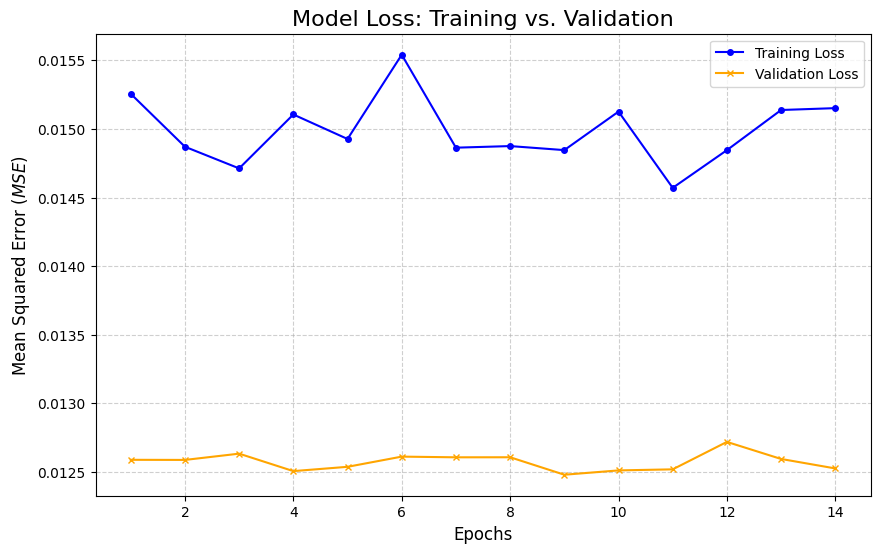

In [36]:
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, val_losses, label='Validation Loss', color='orange', marker='x', markersize=4)
plt.title('Model Loss: Training vs. Validation', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error ($MSE$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [39]:
# 1. Put model in evaluation mode
model.eval()

# 3. Predict without calculating gradients
with torch.no_grad():
    preds_t = model(X_val_t)

# 4. Move back to CPU and convert to NumPy for your metrics function
preds = preds_t.cpu().numpy()

# 5. Run the metrics
avg_psnr, avg_ssim = calculate_metrics(y_val, preds)

print(f"Validation PSNR: {avg_psnr:.2f}")
print(f"Validation SSIM: {avg_ssim:.4f}")

Validation PSNR: 17.67
Validation SSIM: 0.7639


In [ ]:
# Save to Google Drive
torch.save(model.state_dict(), '/content/drive/MyDrive/AI_project/underwater_model1.pth')

In [ ]:
loss_history = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'val_loss': val_losses
})

loss_history.to_csv('/content/drive/MyDrive/AI_project/loss_results1.csv', index=False)